# AI Echo: Your Smartest Conversational Partner
## Sentiment Analysis on ChatGPT User Reviews
### Domain: Customer Experience & Business Analytics

In [13]:
# Install required libraries
# Run this only once
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl


In [14]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
print("All libraries imported successfully!")


All libraries imported successfully!


In [15]:
# Load Dataset
df = pd.read_excel("C:/Users/abish/OneDrive/Desktop/AI_Echo_Project/data/chatgpt_style_reviews_dataset.xlsx")

print("Dataset Loaded!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Loaded!
Shape: (500, 12)

First 5 rows:


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [16]:
# Dataset Info & Missing Values
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               500 non-null    object
 1   title              500 non-null    object
 2   review             500 non-null    object
 3   rating             500 non-null    int64 
 4   username           500 non-null    object
 5   helpful_votes      500 non-null    int64 
 6   review_length      500 non-null    int64 
 7   platform           500 non-null    object
 8   language           500 non-null    object
 9   location           500 non-null    object
 10  version            500 non-null    object
 11  verified_purchase  500 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.0+ KB
None

=== Missing Values ===
date                 0
title                0
review               0
rating               0
username             0
helpful_votes        

,rating,helpful_votes,review_length
count,500.000000,500.000000,500.000000
mean,3.012000,103.090000,6.934000
std,1.366598,57.747896,1.453916
min,1.000000,0.000000,5.000000
25%,2.000000,55.750000,6.000000
50%,3.000000,104.500000,7.000000
75%,4.000000,152.000000,8.000000
max,5.000000,200.000000,10.000000


---
## Data Preprocessing
- Convert text to lowercase
- Remove special characters, URLs, numbers
- Remove stopwords
- Tokenization


In [18]:
# Define stopwords and text cleaning function
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs',
    'themselves','what','which','who','whom','this','that','these',
    'those','am','is','are','was','were','be','been','being','have',
    'has','had','having','do','does','did','doing','a','an','the',
    'and','but','if','or','because','as','until','while','of','at',
    'by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both',
    'each','few','more','most','other','some','such','no','nor','not',
    'only','own','same','so','than','too','very','s','t','can','will',
    'just','don','should','now','ve','ll','re','won','didn'
])

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+', '', text)             # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # remove special chars & numbers
    tokens = text.split()                           # tokenize
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 2]  # remove stopwords
    return " ".join(tokens)

print("Clean function defined!")

# Test on sample
sample = "Not satisfied, many bugs and issues!"
print("Original :", sample)
print("Cleaned  :", clean_text(sample))


Clean function defined!
Original : Not satisfied, many bugs and issues!
Cleaned  : satisfied many bugs issues


In [19]:
# Apply preprocessing to dataset
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['cleaned_review'] = df['review'].apply(clean_text)
df['cleaned_title']  = df['title'].apply(clean_text)

# Drop rows with missing review or rating
df.dropna(subset=['review', 'rating'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Preprocessing Complete!")
print("Total rows after cleaning:", len(df))
print("\nSample comparison:")
df[['review', 'cleaned_review']].head(5)


Preprocessing Complete!
Total rows after cleaning: 500

Sample comparison:


,review,cleaned_review
0,"Not satisfied, many bugs and issues.",satisfied many bugs issues
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements
3,Poor performance and not user-friendly.,poor performance userfriendly
4,"Not satisfied, many bugs and issues.",satisfied many bugs issues


---
## Create Sentiment Labels : Mapping ratings to sentiment:
- (4–5) --> **Positive**
- (3) --> **Neutral**
- (1–2) --> **Negative**


In [20]:
# Create Sentiment Labels from Rating
def label_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(label_sentiment)

print("Sentiment Labels Created!")
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nPercentage:")
print(round(df['sentiment'].value_counts(normalize=True) * 100, 2))


Sentiment Labels Created!

Sentiment Distribution:
sentiment
Positive    200
Negative    195
Neutral     105
Name: count, dtype: int64

Percentage:
sentiment
Positive    40.0
Negative    39.0
Neutral     21.0
Name: proportion, dtype: float64


---
## Exploratory Data Analysis (EDA)
Visualizing patterns in the dataset before model training.


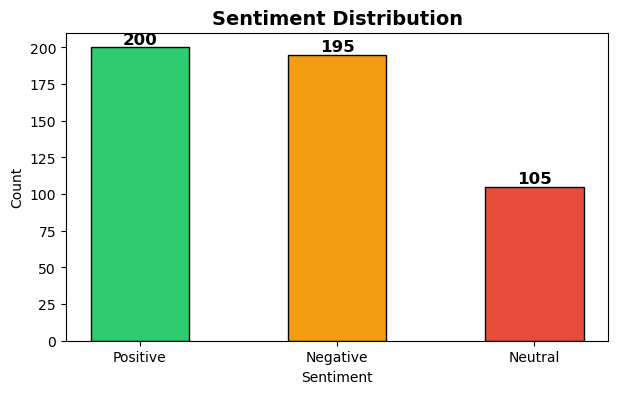

In [22]:
# EDA - Sentiment Distribution
plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
sent_counts = df['sentiment'].value_counts()

bars = plt.bar(sent_counts.index, sent_counts.values, color=colors, edgecolor='black', width=0.5)
plt.title("Sentiment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment"); plt.ylabel("Count")

for bar, val in zip(bars, sent_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 2,
             str(val), ha='center', fontweight='bold', fontsize=12)

plt.show()


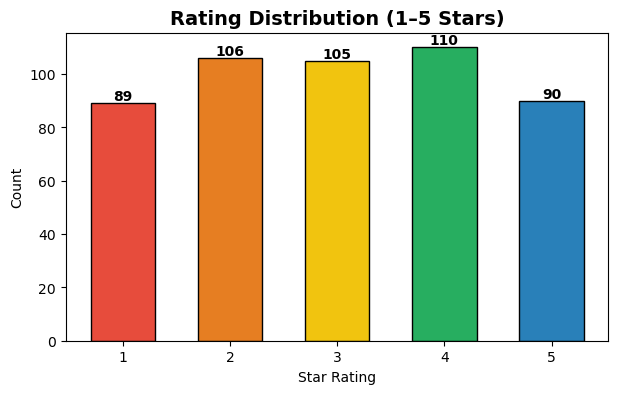

In [23]:
# EDA - Rating Distribution (1-5 Stars)
plt.figure(figsize=(7, 4))
rating_colors = ['#e74c3c','#e67e22','#f1c40f','#27ae60','#2980b9']
rc = df['rating'].value_counts().sort_index()

bars = plt.bar(rc.index.astype(str), rc.values, color=rating_colors, edgecolor='black', width=0.6)
plt.title("Rating Distribution (1–5 Stars)", fontsize=14, fontweight='bold')
plt.xlabel("Star Rating"); plt.ylabel("Count")

for bar, val in zip(bars, rc.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1,
             str(val), ha='center', fontweight='bold')

plt.show()


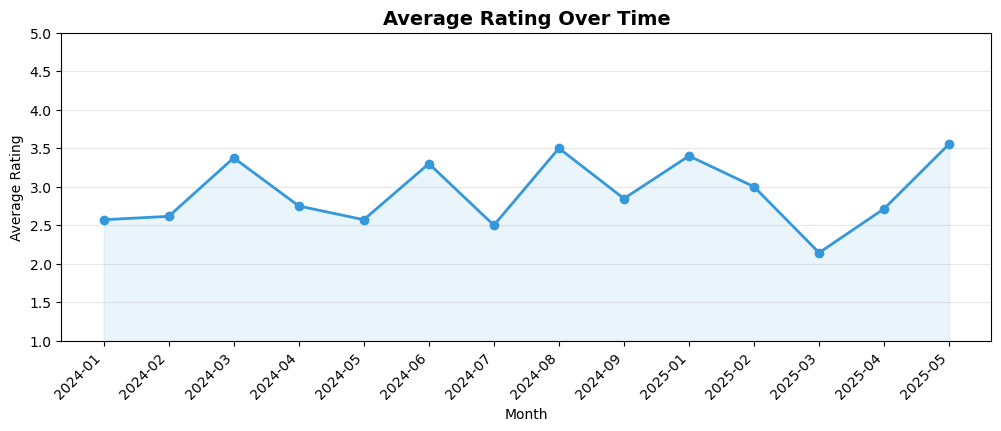

In [24]:
# EDA - Average Rating Over Time (Line Chart)
df_time = df.groupby(df['date'].dt.to_period('M'))['rating'].mean().reset_index()
df_time['date'] = df_time['date'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(df_time['date'], df_time['rating'],
         marker='o', color='#3498db', linewidth=2, markersize=6)
plt.fill_between(range(len(df_time)), df_time['rating'], alpha=0.1, color='#3498db')
plt.title("Average Rating Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Month"); plt.ylabel("Average Rating")
plt.xticks(range(len(df_time)), df_time['date'], rotation=45, ha='right')
plt.ylim(1, 5); plt.grid(axis='y', alpha=0.3)

plt.show()


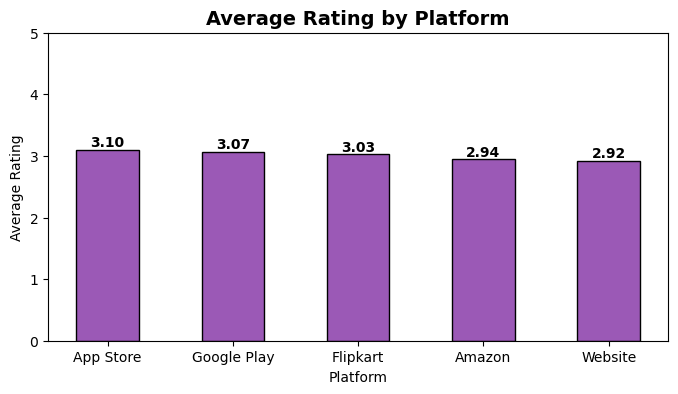

In [25]:
# EDA - Platform vs Average Rating
plt.figure(figsize=(8, 4))
plat = df.groupby('platform')['rating'].mean().sort_values(ascending=False)

bars = plt.bar(plat.index, plat.values, color='#9b59b6', edgecolor='black', width=0.5)
plt.title("Average Rating by Platform", fontsize=14, fontweight='bold')
plt.xlabel("Platform"); plt.ylabel("Average Rating")
plt.ylim(0, 5)

for bar, val in zip(bars, plat.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f"{val:.2f}", ha='center', fontweight='bold')

plt.show()


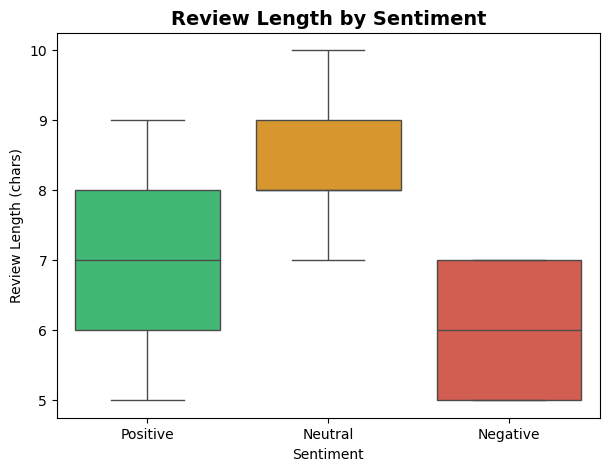

In [26]:
# EDA - Review Length vs Sentiment (Box Plot)
plt.figure(figsize=(7, 5))
colors_map = {'Positive':'#2ecc71', 'Neutral':'#f39c12', 'Negative':'#e74c3c'}

sns.boxplot(data=df, x='sentiment', y='review_length',
            order=['Positive','Neutral','Negative'],
            palette=colors_map)
plt.title("Review Length by Sentiment", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment"); plt.ylabel("Review Length (chars)")

plt.show()


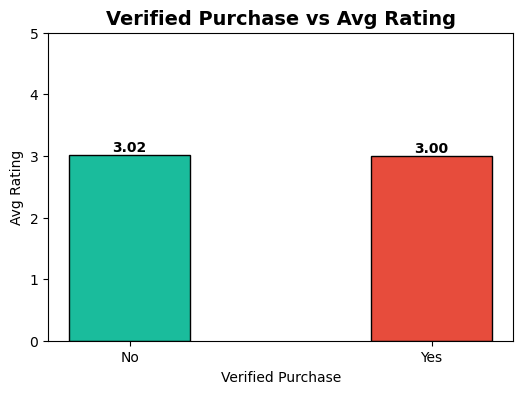

In [27]:
# EDA - Verified Purchase vs Average Rating
plt.figure(figsize=(6, 4))
vp = df.groupby('verified_purchase')['rating'].mean()

bars = plt.bar(vp.index, vp.values, color=['#1abc9c','#e74c3c'], edgecolor='black', width=0.4)
plt.title("Verified Purchase vs Avg Rating", fontsize=14, fontweight='bold')
plt.xlabel("Verified Purchase"); plt.ylabel("Avg Rating")
plt.ylim(0, 5)

for bar, val in zip(bars, vp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f"{val:.2f}", ha='center', fontweight='bold')

plt.show()


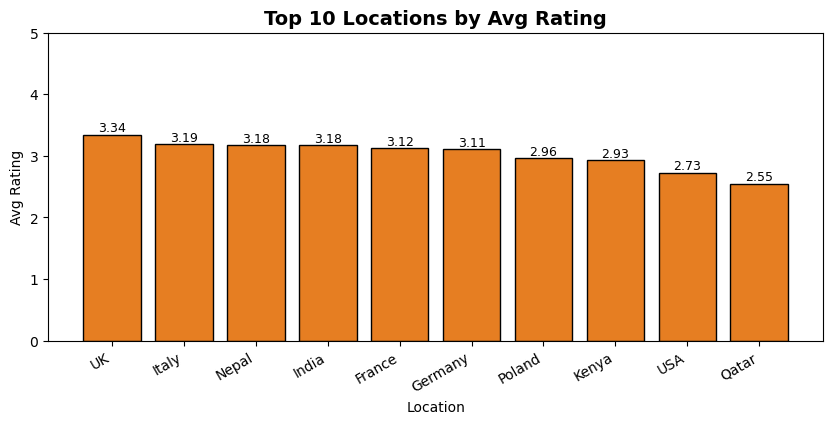

In [28]:
# EDA - Top 10 Locations by Avg Rating
plt.figure(figsize=(10, 4))
loc_rating = df.groupby('location')['rating'].mean().sort_values(ascending=False).head(10)

bars = plt.bar(loc_rating.index, loc_rating.values, color='#e67e22', edgecolor='black')
plt.title("Top 10 Locations by Avg Rating", fontsize=14, fontweight='bold')
plt.xlabel("Location"); plt.ylabel("Avg Rating")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 5)

for bar, val in zip(bars, loc_rating.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f"{val:.2f}", ha='center', fontsize=9)

plt.show()


---
## Top Keywords per Sentiment
Replacing WordCloud with keyword frequency bar charts.
(To use WordCloud locally: pip install wordcloud)


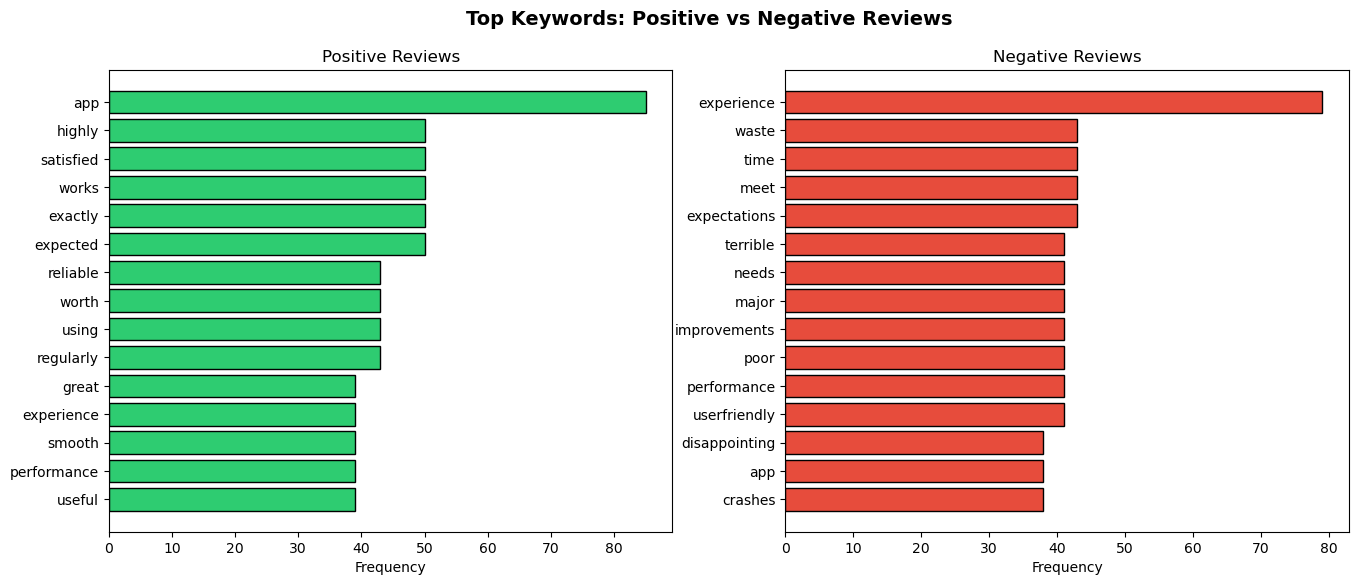

In [31]:
# Top Keywords - Positive vs Negative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top Keywords: Positive vs Negative Reviews",
             fontsize=14, fontweight='bold')

def top_words(texts, n=15):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

pos_w = top_words(df[df['sentiment']=='Positive']['cleaned_review'])
neg_w = top_words(df[df['sentiment']=='Negative']['cleaned_review'])

w1, c1 = zip(*pos_w)
w2, c2 = zip(*neg_w)

axes[0].barh(list(w1)[::-1], list(c1)[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title("Positive Reviews", fontsize=12)
axes[0].set_xlabel("Frequency")

axes[1].barh(list(w2)[::-1], list(c2)[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title("Negative Reviews", fontsize=12)
axes[1].set_xlabel("Frequency")

plt.show()


---
## TF-IDF Feature Engineering
Converting text into numbers using TF-IDF Vectorizer
- max_features = 5000 (top 5000 words)
- ngram_range = (1,2) means single words + word pairs


In [32]:
# TF-IDF Vectorization & Train-Test Split
X = df['cleaned_review']
y = df['sentiment']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF Vectorization Done!")
print(f"Train size : {X_train_tfidf.shape}")
print(f"Test size  : {X_test_tfidf.shape}")
print(f"\nTrain labels:\n{y_train.value_counts()}")
print(f"\nTest labels:\n{y_test.value_counts()}")


TF-IDF Vectorization Done!
Train size : (400, 113)
Test size  : (100, 113)

Train labels:
sentiment
Positive    160
Negative    156
Neutral      84
Name: count, dtype: int64

Test labels:
sentiment
Positive    40
Negative    39
Neutral     21
Name: count, dtype: int64


---
## Train Machine Learning Models
Training 3 models and comparing their performance:
1. Naive Bayes
2. Logistic Regression
3. Random Forest


In [33]:
# Model 1 - Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, nb_pred)
print("=" * 40)
print(f"  Naive Bayes — Accuracy: {nb_acc:.4f}")
print("=" * 40)
print(classification_report(y_test, nb_pred))


  Naive Bayes — Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [34]:
# Model 2 - Logistic Regression
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)
print("=" * 40)
print(f"  Logistic Regression — Accuracy: {lr_acc:.4f}")
print("=" * 40)
print(classification_report(y_test, lr_pred))


  Logistic Regression — Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [35]:
# Model 3 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

rf_acc = accuracy_score(y_test, rf_pred)
print("=" * 40)
print(f"  Random Forest — Accuracy: {rf_acc:.4f}")
print("=" * 40)
print(classification_report(y_test, rf_pred))


  Random Forest — Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



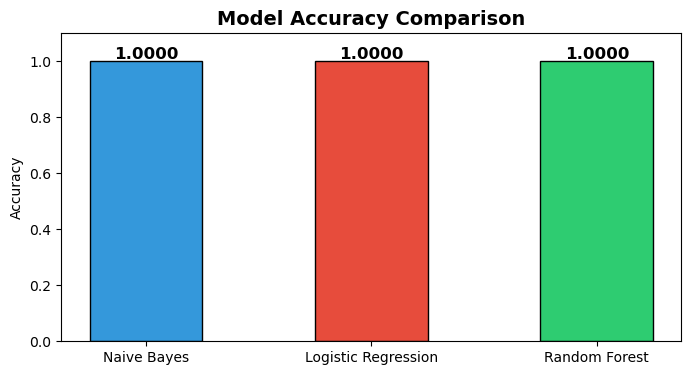

In [37]:
# Model Accuracy Comparison Chart
model_names  = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
model_scores = [nb_acc, lr_acc, rf_acc]

plt.figure(figsize=(8, 4))
bars = plt.bar(model_names, model_scores,
               color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy"); plt.ylim(0, 1.1)

for bar, val in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.4f}", ha='center', fontweight='bold', fontsize=12)

plt.show()

# Pick Best Model
best_idx   = model_scores.index(max(model_scores))
best_name  = model_names[best_idx]
best_model = [nb_model, lr_model, rf_model][best_idx]


---
## Model Evaluation
- Confusion Matrix
- AUC-ROC Score


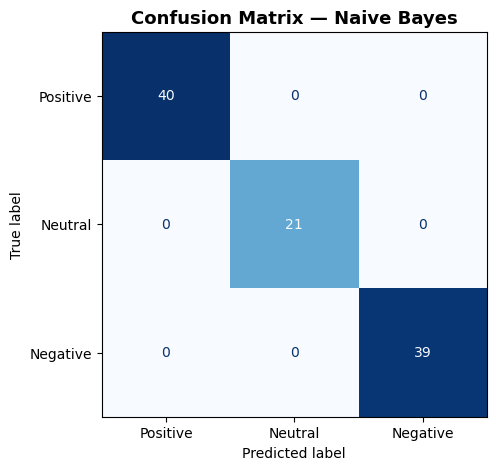

In [39]:
# Confusion Matrix of Best Model
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, best_model.predict(X_test_tfidf),
                      labels=['Positive','Neutral','Negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Positive','Neutral','Negative'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')

plt.show()


In [42]:
# AUC-ROC Score (Multiclass)
classes_order = best_model.classes_.tolist()
y_test_bin    = label_binarize(y_test, classes=classes_order)
y_prob        = best_model.predict_proba(X_test_tfidf)

auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')

print(f"  AUC-ROC Score (macro avg): {auc:.4f}")


  AUC-ROC Score (macro avg): 1.0000


---
## Save Model & Vectorizer
Saving model.pkl and tfidf_vectorizer.pkl for Streamlit deployment


In [43]:
# Save Best Model & TF-IDF Vectorizer
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save cleaned dataset
df.to_csv("cleaned_reviews.csv", index=False)



In [46]:
# Summary

print(f"Total Reviews     : {len(df)}")
print(f"Positive Reviews  : {len(df[df['sentiment']=='Positive'])}")
print(f"Neutral Reviews   : {len(df[df['sentiment']=='Neutral'])}")
print(f"Negative Reviews  : {len(df[df['sentiment']=='Negative'])}")
print("\n")
print(f"Naive Bayes Acc.  : {nb_acc:.4f}")
print(f"Logistic Reg Acc. : {lr_acc:.4f}")
print(f"Random Forest Acc : {rf_acc:.4f}")
print("\n")
print(f"Selected Model        : {best_name}")
print(f"AUC-ROC Score     : {auc:.4f}")

Total Reviews     : 500
Positive Reviews  : 200
Neutral Reviews   : 105
Negative Reviews  : 195


Naive Bayes Acc.  : 1.0000
Logistic Reg Acc. : 1.0000
Random Forest Acc : 1.0000


Selected Model        : Naive Bayes
AUC-ROC Score     : 1.0000
